In [1]:
import os
import numpy as np
import efficientnet.tfkeras
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model, model_from_json
from tensorflow.keras import optimizers
 
os.environ["CUDA_VISIBLE_DEVICES"]= "1"

In [2]:
path_model = "/media/tohn/HDD2/Model_unlearn/Models_USAI/ML-unlearn/R2_balanced/unfreezeBlock5a_se_excite/models/modelEffNetB5_ML-unlearn_unfreezeBlock5a_se_excite-R2_balanced.h5"
model = load_model(path_model)
height = width = model.input_shape[1]
input_shape = (height, width, 3)
print(input_shape)
print("*"*125)
model.summary()

(456, 456, 3)
*****************************************************************************************************************************
Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
new_input (InputLayer)       [(None, 456, 456, 3)]     0         
_________________________________________________________________
efficientnet-b5 (Functional) (None, None, None, 2048)  28513520  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dropout (Dropout)            (None, 2048)              0         
_________________________________________________________________
prediction_layer (Dense)     (None, 15)                30735     
Total params: 28,544,255
Trainable params: 26,109,423
Non-trainable params: 2,434,832
_________________________________

In [3]:
# validation
import pandas as pd
base_dir = '/media/tohn/SSD/Images/Image1'
dataframe = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Valdf_fold3_v2.csv')#แก้
validation_dir = os.path.join(base_dir, 'test')

#Train
train_df = pd.read_csv( '/media/tohn/HDD/VISION_dataset/Traindf_fold4_8_v2.csv')#แก้
base_dir = '/media/tohn/SSD/Images/Image1'
os.chdir(base_dir)
train_dir = os.path.join(base_dir, 'train')

In [4]:
import pandas as pd
df0 = pd.read_csv('/media/tohn/HDD/VISION_dataset/Testdf_fold1_2_v1.csv')
print(df0 .shape)
dataframe = df0[(df0['Path Crop']!='None' )&(df0['Path Crop']!='Nan')]
print(dataframe.shape)
# print('Normal: ',dataframe[dataframe['Class']=='Normal'].shape)
# print('Abnormal: ',dataframe[dataframe['Class']=='Abnormal'].shape)
dataframe.head(5)

(1312, 27)
(1312, 27)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Rwidth,Rheight,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.513514,0.346614,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,0.560377,0.428287,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.667984,0.711155,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,0.690385,0.653386,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,0.672515,0.625498,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3


In [5]:
len(set(dataframe['Sub_class_New']))

15

In [6]:
batch_size = 16

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = dataframe,
        directory = train_dir,
        x_col = 'Path Crop',
        y_col = 'Sub_class_New',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 1312 validated image filenames belonging to 15 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB04', 4: 'AB05', 5: 'AB06', 6: 'AB07', 7: 'AB081', 8: 'AB082', 9: 'AB083', 10: 'AB09', 11: 'AB10', 12: 'AB11', 13: 'AB12', 14: 'Normal'}


# Prediction

In [8]:
from tensorflow.keras.preprocessing import image
def predict_image(img_path):
    # Read the image and resize it
    img = image.load_img(img_path, target_size=(height, width))
    # Convert it to a Numpy array with target shape.
    x = image.img_to_array(img)
    # Reshape
    x = x.reshape((1,) + x.shape)
    x /= 255.
    result = model.predict([x])
    
    return result[0]

#Predict
pred_list = list()
prob_list = list()
img_path=dataframe['Path Crop'].tolist()
for i in range(0,len(img_path)):
    predict = predict_image(img_path[i])
    result = np.argmax(predict)
    pred_list.append(labels[result])
    prob_list.append(predict[result])
    print("Image :", i+1)

Image : 1
Image : 2
Image : 3
Image : 4
Image : 5
Image : 6
Image : 7
Image : 8
Image : 9
Image : 10
Image : 11
Image : 12
Image : 13
Image : 14
Image : 15
Image : 16
Image : 17
Image : 18
Image : 19
Image : 20
Image : 21
Image : 22
Image : 23
Image : 24
Image : 25
Image : 26
Image : 27
Image : 28
Image : 29
Image : 30
Image : 31
Image : 32
Image : 33
Image : 34
Image : 35
Image : 36
Image : 37
Image : 38
Image : 39
Image : 40
Image : 41
Image : 42
Image : 43
Image : 44
Image : 45
Image : 46
Image : 47
Image : 48
Image : 49
Image : 50
Image : 51
Image : 52
Image : 53
Image : 54
Image : 55
Image : 56
Image : 57
Image : 58
Image : 59
Image : 60
Image : 61
Image : 62
Image : 63
Image : 64
Image : 65
Image : 66
Image : 67
Image : 68
Image : 69
Image : 70
Image : 71
Image : 72
Image : 73
Image : 74
Image : 75
Image : 76
Image : 77
Image : 78
Image : 79
Image : 80
Image : 81
Image : 82
Image : 83
Image : 84
Image : 85
Image : 86
Image : 87
Image : 88
Image : 89
Image : 90
Image : 91
Image : 

Image : 695
Image : 696
Image : 697
Image : 698
Image : 699
Image : 700
Image : 701
Image : 702
Image : 703
Image : 704
Image : 705
Image : 706
Image : 707
Image : 708
Image : 709
Image : 710
Image : 711
Image : 712
Image : 713
Image : 714
Image : 715
Image : 716
Image : 717
Image : 718
Image : 719
Image : 720
Image : 721
Image : 722
Image : 723
Image : 724
Image : 725
Image : 726
Image : 727
Image : 728
Image : 729
Image : 730
Image : 731
Image : 732
Image : 733
Image : 734
Image : 735
Image : 736
Image : 737
Image : 738
Image : 739
Image : 740
Image : 741
Image : 742
Image : 743
Image : 744
Image : 745
Image : 746
Image : 747
Image : 748
Image : 749
Image : 750
Image : 751
Image : 752
Image : 753
Image : 754
Image : 755
Image : 756
Image : 757
Image : 758
Image : 759
Image : 760
Image : 761
Image : 762
Image : 763
Image : 764
Image : 765
Image : 766
Image : 767
Image : 768
Image : 769
Image : 770
Image : 771
Image : 772
Image : 773
Image : 774
Image : 775
Image : 776
Image : 777
Imag

In [9]:
dataframe['category'] = pred_list
dataframe['Prob'] = prob_list
dataframe.head()

,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,Normal,0.999952
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.997372
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,1.000000
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999420


In [10]:
dataframe.to_csv("/home/kannika/code/Result_EffNetB5_ML-unlearn_unfreezeBlock5a_se_excite-R2_balanced.csv")

# Evaluation

In [11]:
data_train = dataframe
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB10', 'AB07', 'Normal', 'AB083', 'AB02', 'AB03', 'AB081', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}
Actual :  15
{'AB10', 'AB07', 'AB083', 'Normal', 'AB02', 'AB081', 'AB03', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 87.1951219512195%
              precision    recall  f1-score   support

        AB01       0.76      0.57      0.65        74
        AB02       0.51      0.47      0.49        59
        AB03       0.41      0.58      0.48        19
        AB04       0.87      0.68      0.76        38
        AB05       0.81      0.72      0.76        29
        AB06       0.67      0.48      0.56        21
        AB07       0.71      0.57      0.63        21
       AB081       0.82      0.56      0.67        32
       AB082       0.82      0.50      0.62        28
       AB083       0.45      0.45      0.45        11
        AB09       0.83      0.92      0.87        26
        AB10       0.88      0.70      0.78        10
        AB11       0.98      0.91      0.94        55
        AB12       0.91      0.91      0.91        32
      Normal       0.92      0.99      0.95       857

    accuracy                           0.87      1312
   macro avg       0.76      0.67      0

Text(0.5, 21.5, 'Predicted label')

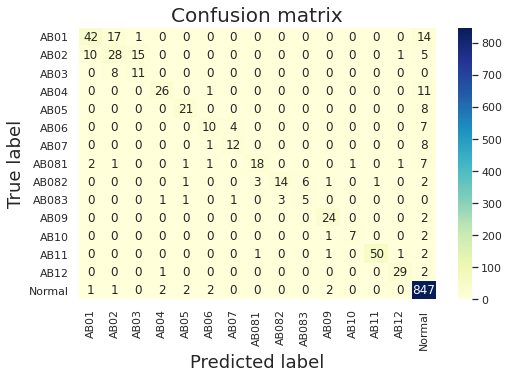

In [13]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

In [14]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 93.90243902439025%
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       857
           1       0.97      0.85      0.91       455

    accuracy                           0.94      1312
   macro avg       0.95      0.92      0.93      1312
weighted avg       0.94      0.94      0.94      1312



847 10 70 385


Text(48.5, 0.5, 'True label')

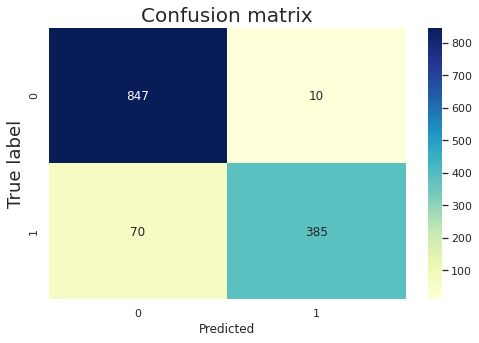

In [15]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)
TN, FP, FN, TP = confusion_matrix(act, pred).ravel()
print(TN, FP, FN, TP)
#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)

In [16]:
Sub_class_New = list(set(dataframe['Sub_class_New']))

for i in range(len(Sub_class_New)):
    df = dataframe[dataframe['Sub_class_New'] == Sub_class_New[i]]
    
    act = df['Sub_class_New'].array
    pred = df['category'].array

    cmat = confusion_matrix(act, pred)
    print('######', Sub_class_New[i])
#     print(cmat)
#     print(classification_report(act, pred))
    
    print('classifier accuracy = {}% \n'.format((np.trace(cmat))/(np.sum(cmat))))

###### AB10
classifier accuracy = 0.7% 

###### AB07
classifier accuracy = 0.5714285714285714% 

###### AB083
classifier accuracy = 0.45454545454545453% 

###### Normal
classifier accuracy = 0.9883313885647608% 

###### AB02
classifier accuracy = 0.4745762711864407% 

###### AB081
classifier accuracy = 0.5625% 

###### AB03
classifier accuracy = 0.5789473684210527% 

###### AB01
classifier accuracy = 0.5675675675675675% 

###### AB05
classifier accuracy = 0.7241379310344828% 

###### AB082
classifier accuracy = 0.5% 

###### AB04
classifier accuracy = 0.6842105263157895% 

###### AB12
classifier accuracy = 0.90625% 

###### AB09
classifier accuracy = 0.9230769230769231% 

###### AB06
classifier accuracy = 0.47619047619047616% 

###### AB11
classifier accuracy = 0.9090909090909091% 



# Exclude Normal classes

In [17]:
dataframe

,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,Normal,0.999952
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.997372
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,1.000000
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,6550,350,P3,P32,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,2,Normal,...,Normal,NaN,NaN,False,Test,P9,P3-2.Case 350.JPG,P9,Normal,1.000000
1308,6551,350,P4,P42,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-B,2,Normal,...,Normal,Easy,Easy,False,Test,P5,P4-2.Case 350.JPG,P5,Normal,0.999954
1309,6552,350,P5,P52,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,2,Normal,...,Normal,Easy,Easy,True,Test,None,P5-2.Case 350.JPG,P7,Normal,1.000000
1310,6553,350,P6,P61,Normal,/media/tohn/HDD/VISION_dataset/USAI/US images ...,/media/tohn/HDD/VISION_dataset/USAI/US images ...,FP-C,2,Normal,...,Normal,Hard,Easy,True,Test,P14,P6.Case 350.JPG,P14,Normal,1.000000


In [18]:
dataframe_ = dataframe[dataframe["Sub_class_New"]!="Normal"].reset_index(drop=True)
print(dataframe_.shape)
dataframe_

(455, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,111,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P1,AB01 P1 C040.JPG,P1,Normal,0.999952
1,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
2,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.997372
3,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,1.000000
4,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB081,0.907848
451,2262,340,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 182.JPG.png,P12,Normal,0.999947
452,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,1.000000
453,2269,343,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,2,Hydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 185.JPG.png,P12,AB11,1.000000


In [19]:
##**Normal == 857 images
455+857

1312

In [20]:
data_train = dataframe_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  15
{'AB10', 'AB07', 'Normal', 'AB083', 'AB02', 'AB03', 'AB081', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}
Actual :  14
{'AB10', 'AB07', 'AB083', 'AB02', 'AB081', 'AB03', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}


In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 65.27472527472527%
              precision    recall  f1-score   support

        AB01       0.78      0.57      0.66        74
        AB02       0.52      0.47      0.50        59
        AB03       0.41      0.58      0.48        19
        AB04       0.93      0.68      0.79        38
        AB05       0.88      0.72      0.79        29
        AB06       0.77      0.48      0.59        21
        AB07       0.71      0.57      0.63        21
       AB081       0.82      0.56      0.67        32
       AB082       0.82      0.50      0.62        28
       AB083       0.45      0.45      0.45        11
        AB09       0.89      0.92      0.91        26
        AB10       0.88      0.70      0.78        10
        AB11       0.98      0.91      0.94        55
        AB12       0.91      0.91      0.91        32
      Normal       0.00      0.00      0.00         0

    accuracy                           0.65       455
   macro avg       0.72      0.60      

/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [22]:
# act= p1['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
act= data_train['Sub_class_New'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
pred = data_train['category'].map({'AB12':1, 'AB04':1, 'AB05':1, 'Normal':0, 'AB02':1, 'AB11':1, 'AB082':1, 'AB06':1,'AB07':1, 'AB081':1, 'AB09':1, 'AB03':1, 'AB10':1, 'AB01':1, 'AB083':1}).values
cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 84.61538461538461%
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.85      0.92       455

    accuracy                           0.85       455
   macro avg       0.50      0.42      0.46       455
weighted avg       1.00      0.85      0.92       455



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Text(0.5, 21.5, 'Predicted label')

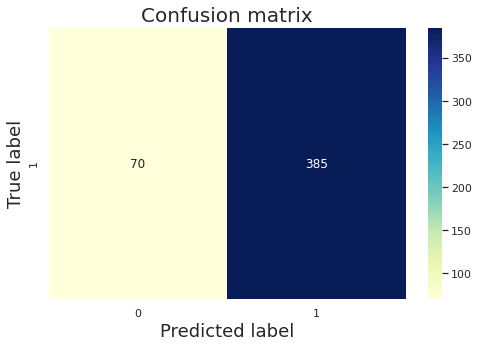

In [23]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

--------------------

In [24]:
dataframe0_ = dataframe[(dataframe["Sub_class_New"]!="Normal") & (dataframe['category']!="Normal")].reset_index(drop=True)
print(dataframe0_.shape)
dataframe0_

(385, 29)


,Unnamed: 0,Case,Abs Position,Sub Position,Class,Path Full,Path Crop,Views,fold,15AB,...,Sub_class_New,tag_AjNit,tag_AjWan,Test150,Spilt,Sub_Position_New,filename,Sub_Position_Label,category,Prob
0,112,40,P2,P2,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P2,AB01 P2 C040.JPG,P2,AB01,1.000000
1,113,40,P4,P41,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P4,AB01 P4-1 C040.JPG,P4,AB01,0.997372
2,114,40,P5,P51,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-C,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P6,AB01 P5-1 C040.JPG,P6,AB01,1.000000
3,115,40,P3,P31,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-B,2,MildFattyLiver,...,AB01,NaN,NaN,False,Test,P3,AB01 P3-1 C040.JPG,P3,AB02,0.999420
4,116,40,P1,P1,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,/media/tohn/HDD/VISION_dataset/USAI/ABnormal01...,FP-A,2,ModerateFattyLiver,...,AB02,NaN,NaN,False,Test,P1,AB02 P1 C040.JPG,P1,AB02,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,2247,301,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,RenalCyst,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 143.JPG.png,P12,AB11,0.597966
381,2253,300,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Renalstones,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 142.JPG.png,P12,AB081,0.907848
382,2265,361,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,1,Hydronephrosis,...,AB11,Easy,Hard,False,Test,P12,FP D P7-2 Case 203.JPG.png,P12,AB11,1.000000
383,2269,343,P7,P72,Abnormal,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,/media/tohn/HDD/VISION_dataset/USAI/FPD JULY 2...,FP-D,2,Hydronephrosis,...,AB11,NaN,NaN,False,Test,P12,FP D P7-2 Case 185.JPG.png,P12,AB11,1.000000


In [25]:
data_train = dataframe0_
#เช็คคลาสใน Predicted
pred_class = set(data_train['category'])
print('Predicted : ',len(pred_class))
print(pred_class)
#เช็คคลาสใน Actual
classe = set(data_train['Sub_class_New'])
print('Actual : ',len(classe))
print(classe)

Predicted :  14
{'AB10', 'AB07', 'AB083', 'AB02', 'AB03', 'AB081', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}
Actual :  14
{'AB10', 'AB07', 'AB083', 'AB02', 'AB081', 'AB03', 'AB01', 'AB05', 'AB082', 'AB04', 'AB12', 'AB09', 'AB06', 'AB11'}


In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix

act = data_train['Sub_class_New'].array
pred = data_train['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 77.14285714285714%
              precision    recall  f1-score   support

        AB01       0.78      0.70      0.74        60
        AB02       0.52      0.52      0.52        54
        AB03       0.41      0.58      0.48        19
        AB04       0.93      0.96      0.95        27
        AB05       0.88      1.00      0.93        21
        AB06       0.77      0.71      0.74        14
        AB07       0.71      0.92      0.80        13
       AB081       0.82      0.72      0.77        25
       AB082       0.82      0.54      0.65        26
       AB083       0.45      0.45      0.45        11
        AB09       0.89      1.00      0.94        24
        AB10       0.88      0.88      0.88         8
        AB11       0.98      0.94      0.96        53
        AB12       0.91      0.97      0.94        30

    accuracy                           0.77       385
   macro avg       0.77      0.78      0.77       385
weighted avg       0.78      0.77      

Text(0.5, 21.5, 'Predicted label')

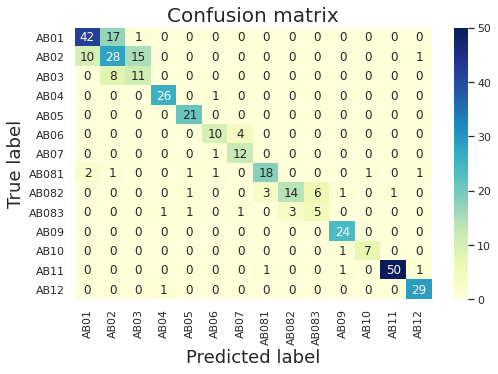

In [27]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)